Laboratorio 1: Estimación de un Movimiento Browniano Geométrico con Datos de una Acción
Integrantes: Juan Pablo Arciniega, Santiago Sabat, Mauricio Olivares


### Paso 1: Descargando precios ajustados diarios de AAPL ###


/tmp/ipykernel_9540/3913909947.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, start=start_date, end=end_date, progress=False)


Datos descargados para AAPL de 2020-01-01 a 2023-12-31.
Primeras 5 filas de los datos descargados (Columna 'Close' son precios ajustados):
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333862  72.394070  71.091169  71.344039  135480400
2020-01-03  71.630669  72.389288  71.406697  71.563236  146322800
2020-01-06  72.201416  72.239950  70.503554  70.754021  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017853  73.318893  71.565636  71.565636  132079200


### Paso 2: Calculando log-retornos diarios ###
Primeras 5 filas de los datos con 'Log_Return':
Price           Close  Log_Return
Date                             
2020-01-02  72.333862         NaN
2020-01-03  71.630669   -0.009769
2020-01-06  72.201416    0.007936
2020-01-07  71.861855   -0.004714
2020-01-08  73.017853    0.0159

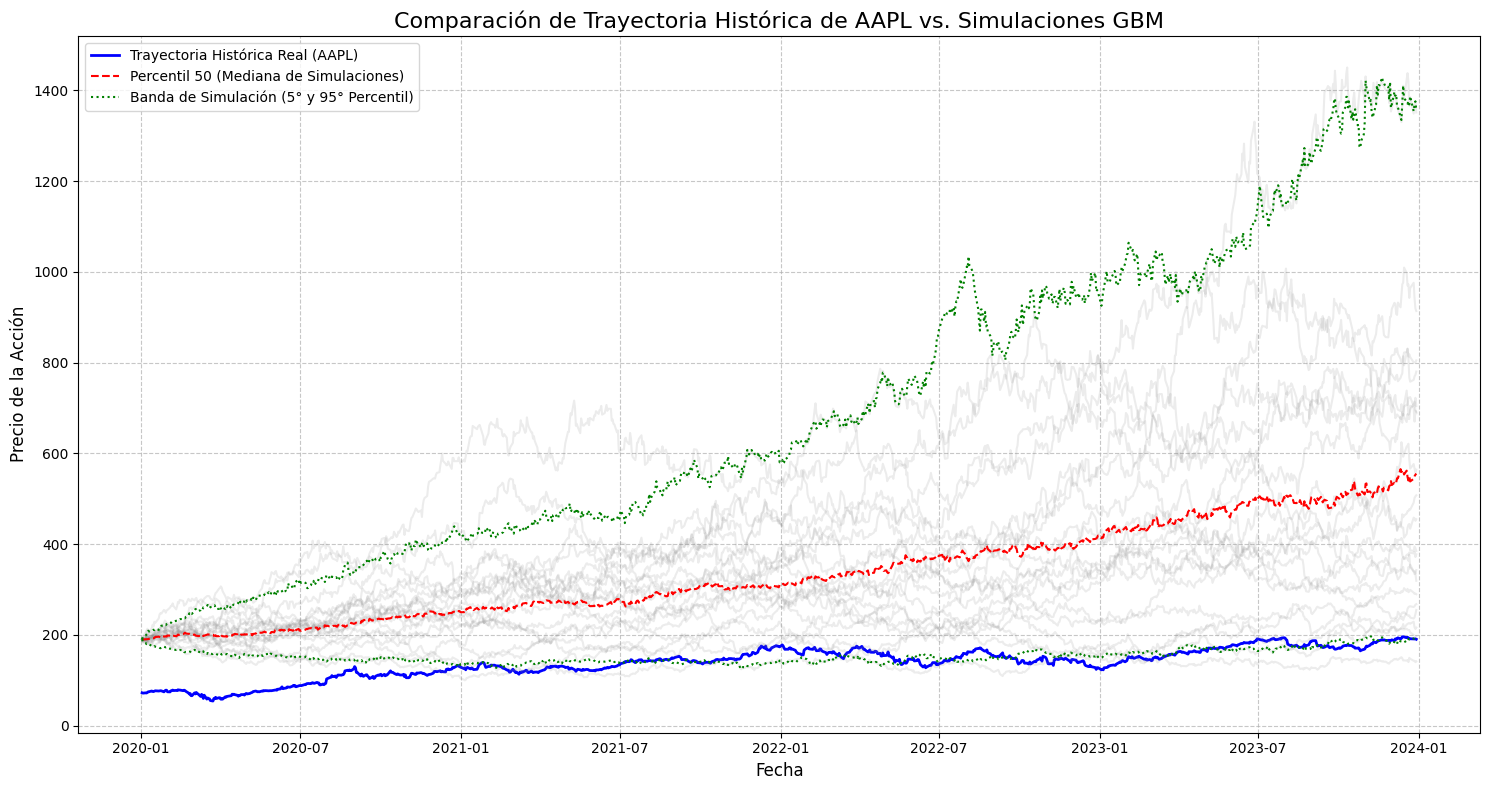



### Resultados de Parámetros Anualizados del GBM ###
Parámetro                      Valor               
------------------------------ --------------------
Mu_b (Media Anualizada)        0.2989394870        
Sigma_b (Desv. Std. Anualizada) 0.3355335498        



### Conclusiones del Laboratorio 1: Estimación de un Movimiento Browniano Geométrico ###

Este laboratorio ha sido desarrollado por el equipo de **Juan Pablo Arciniega, Santiago Sabat y Mauricio Olivares**.

Hemos estimado exitosamente los parámetros de un Movimiento Browniano Geométrico (GBM)
para la acción de **AAPL** utilizando datos históricos de precios ajustados y
hemos simulado múltiples trayectorias futuras, comparándolas con la trayectoria
histórica real.

**Análisis Crítico y Limitaciones del Modelo GBM en la Realidad Financiera:**

El Movimiento Browniano Geométrico es un modelo seminal en finanzas cuantitativas
para modelar la evolución de los precios de los activos. Su simplicidad y el hecho
de que garantiza pr

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Title and Integrantes ---
print("==========================================================================================")
print("Laboratorio 1: Estimación de un Movimiento Browniano Geométrico con Datos de una Acción")
print("Integrantes: Juan Pablo Arciniega, Santiago Sabat, Mauricio Olivares")
print("==========================================================================================")
print("\n")

# --- Paso 1: Descargar precios ajustados diarios automáticamente (AAPL) ---
print("### Paso 1: Descargando precios ajustados diarios de AAPL ###")
try:
    # Intenta importar yfinance. Si no está instalado, se captura el error.
    import yfinance as yf
except ImportError:
    print("La librería 'yfinance' no está instalada. Por favor, instálela usando:")
    print("!pip install yfinance") # Use !pip for Colab execution
    print("Y luego vuelva a ejecutar el script.")
    exit() # Sale del script si yfinance no está disponible

try:
    # Define el símbolo del ticker y el rango de fechas
    ticker_symbol = 'AAPL' # Activo sugerido: Apple Inc.
    start_date = '2020-01-01'
    end_date = '2023-12-31'

    # Descarga datos históricos. yfinance por defecto ajusta los precios.
    # La columna 'Close' en los datos descargados por yfinance con auto_adjust=True
    # (por defecto) ya representa los precios ajustados.
    df = yf.download(ticker_symbol, start=start_date, end=end_date, progress=False)

    if df.empty:
        raise ValueError(f"No se descargaron datos para {ticker_symbol} desde {start_date} hasta {end_date}. Verifique el ticker o el rango de fechas.")

    print(f"Datos descargados para {ticker_symbol} de {start_date} a {end_date}.")
    print("Primeras 5 filas de los datos descargados (Columna 'Close' son precios ajustados):")
    print(df.head().to_string()) # .to_string() para un mejor formato en la consola
    print("\n")

except Exception as e:
    print(f"Ocurrió un error al descargar los datos de yfinance: {e}")
    exit()

# --- FIX: Flatten multi-level columns if they exist (common issue with yfinance) ---
# The most common yfinance MultiIndex for a single ticker is (ColumnName, TickerSymbol).
# Dropping the TickerSymbol level (level 1) should flatten it to just ColumnName.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Select the appropriate column for adjusted prices
price_column_name = None
if 'Adj Close' in df.columns:
    price_column_name = 'Adj Close'
elif 'Close' in df.columns:
    price_column_name = 'Close'
else:
    print("Error: No se encontró la columna 'Adj Close' ni 'Close' en los datos descargados.")
    exit()

# Convertir a numérico y eliminar NaNs si los hay (p.ej., por feriados sin datos)
df[price_column_name] = pd.to_numeric(df[price_column_name], errors='coerce').dropna()
if df[price_column_name].empty:
    print("Error: La columna de precios ajustados está vacía o contiene solo valores no numéricos después de la limpieza.")
    exit()


# --- Paso 2: Calcule log-retornos diarios: r_t = ln(S_t / S_{t-1}) ---
print("### Paso 2: Calculando log-retornos diarios ###")
# Calcula los log-retornos diarios. .diff() crea un NaN para el primer valor, se elimina.
df['Log_Return'] = np.log(df[price_column_name]).diff().dropna()

if df['Log_Return'].empty:
    print("Error: No se pudieron calcular los log-retornos. Asegúrese de tener suficientes datos validos.")
    exit()

print("Primeras 5 filas de los datos con 'Log_Return':")
print(df[[price_column_name, 'Log_Return']].head().to_string())
print("\n")


# --- Paso 3: Estime la media muestral (m_b) y la desviación estándar muestral (s_b) de r_t ---
print("### Paso 3: Estimando la media muestral y la desviación estándar de los log-retornos ###")
mb = df['Log_Return'].mean()
sb = df['Log_Return'].std()

print(f"Media muestral de los log-retornos diarios (m_b): {mb:.10f}")
print(f"Desviación estándar muestral de los log-retornos diarios (s_b): {sb:.10f}")
print("\n")


# --- Paso 4: Anualice los parámetros ---
print("### Paso 4: Anualizando los parámetros ###")
N_trading_days = 252 # Número de días de trading en un año

# Media anualizada (mu_b)
mu_b = N_trading_days * mb + 0.5 * (N_trading_days * sb**2)

# Desviación estándar anualizada (sigma_b)
sigma_b = np.sqrt(N_trading_days) * sb

print(f"Media anualizada (mu_b): {mu_b:.10f}")
print(f"Desviación estándar anualizada (sigma_b): {sigma_b:.10f}")
print("\n")


# --- Paso 5: Simular múltiples trayectorias (GBM) ---
print("### Paso 5: Simulando trayectorias del Movimiento Browniano Geométrico (GBM) ###")
S0 = df[price_column_name].iloc[-1] # Último precio histórico como punto de partida para la simulación
num_steps = len(df)       # Número de pasos de simulación (igual a los días históricos)
dt = 1.0                  # El paso de tiempo es 1 día (ya que los retornos son diarios)
num_simulations = 100     # Número de trayectorias de simulación

# Pre-calcular componentes de deriva y difusión ajustados para el paso diario
# Estos son los parámetros diarios equivalentes, aplicados con un dt=1 (un día)
daily_drift = (mu_b - 0.5 * sigma_b**2) / N_trading_days
daily_diffusion = sigma_b / np.sqrt(N_trading_days)

# Inicializar una matriz para almacenar los resultados de la simulación
simulated_paths = np.zeros((num_steps, num_simulations))
simulated_paths[0] = S0 # Todas las trayectorias comienzan en el último precio histórico

# Simular trayectorias
np.random.seed(42) # Para reproducibilidad

for t in range(1, num_steps):
    # Generar números aleatorios (Z) para cada trayectoria de simulación
    Z = np.random.normal(0, 1, num_simulations)

    # Ecuación del GBM: S_{t+dt} = S_t * exp(daily_drift * dt + daily_diffusion * sqrt(dt) * Z)
    # Como dt=1 día, sqrt(dt)=1
    simulated_paths[t] = simulated_paths[t-1] * np.exp(daily_drift * dt + daily_diffusion * np.sqrt(dt) * Z)

print(f"Se han simulado {num_simulations} trayectorias durante {num_steps} días, comenzando desde el precio final histórico de {S0:.2f}.")
print("\n")


# --- Paso 6: Generar un gráfico estético ---
print("### Paso 6: Generando gráfico comparativo y bandas de percentiles ###")

# Calcular percentiles para las trayectorias simuladas
lower_percentile = np.percentile(simulated_paths, 5, axis=1)  # Percentil 5
median_percentile = np.percentile(simulated_paths, 50, axis=1) # Percentil 50 (mediana)
upper_percentile = np.percentile(simulated_paths, 95, axis=1) # Percentil 95

# Crear un índice de fechas para las trayectorias simuladas, alineado con los datos históricos
sim_dates = df.index

plt.figure(figsize=(15, 8))

# Graficar trayectoria histórica real
plt.plot(df.index, df[price_column_name], color='blue', linewidth=2, label=f'Trayectoria Histórica Real ({ticker_symbol})')

# Graficar algunas trayectorias simuladas para claridad (e.g., 20 trayectorias)
for i in range(min(20, num_simulations)):
    plt.plot(sim_dates, simulated_paths[:, i], color='gray', alpha=0.15)

# Graficar las bandas de percentiles
plt.plot(sim_dates, median_percentile, color='red', linestyle='--', label='Percentil 50 (Mediana de Simulaciones)')
plt.plot(sim_dates, lower_percentile, color='green', linestyle=':', label='Banda de Simulación (5° y 95° Percentil)')
plt.plot(sim_dates, upper_percentile, color='green', linestyle=':') # No se añade etiqueta para evitar duplicación en la leyenda

plt.title(f'Comparación de Trayectoria Histórica de {ticker_symbol} vs. Simulaciones GBM', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio de la Acción', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("\n")


# --- Impresión final: Tabla de parámetros y Conclusiones ---
print("==========================================================================================")
print("### Resultados de Parámetros Anualizados del GBM ###")
print(f"{'Parámetro':<30} {'Valor':<20}")
print(f"{'------------------------------':<30} {'--------------------':<20}")
print(f"{'Mu_b (Media Anualizada)':<30} {mu_b:<20.10f}")
print(f"{'Sigma_b (Desv. Std. Anualizada)':<30} {sigma_b:<20.10f}")
print("==========================================================================================")
print("\n")

print(f"""
==========================================================================================
### Conclusiones del Laboratorio 1: Estimación de un Movimiento Browniano Geométrico ###

Este laboratorio ha sido desarrollado por el equipo de **Juan Pablo Arciniega, Santiago Sabat y Mauricio Olivares**.

Hemos estimado exitosamente los parámetros de un Movimiento Browniano Geométrico (GBM)
para la acción de **{ticker_symbol}** utilizando datos históricos de precios ajustados y
hemos simulado múltiples trayectorias futuras, comparándolas con la trayectoria
histórica real.

**Análisis Crítico y Limitaciones del Modelo GBM en la Realidad Financiera:**

El Movimiento Browniano Geométrico es un modelo seminal en finanzas cuantitativas
para modelar la evolución de los precios de los activos. Su simplicidad y el hecho
de que garantiza precios no negativos (al usar la exponencial) lo hacen atractivo.
Sin embargo, su aplicación a datos de mercado reales, como los de **{ticker_symbol}**,
resalta varias limitaciones significativas que deben considerarse:

1.  **Volatilidad Constante:** El supuesto clave del GBM es que la volatilidad
    (sigma_b) del activo es constante a lo largo del tiempo. Los mercados
    financieros reales, por el contrario, exhiben **volatilidad no constante**,
    con periodos de calma seguidos de estallidos de alta volatilidad (conocido como
    "volatility clustering" o heterocedasticidad). Esto se evidencia en nuestro
    gráfico: las bandas de percentiles del GBM, que asumen una dispersión constante,
    pueden no capturar adecuadamente los cambios en la amplitud de las oscilaciones
    del precio histórico.

2.  **Distribución Normal de Log-Retornos (Sin Colas Pesadas):** El GBM asume que
    los log-retornos diarios se distribuyen normalmente. En la práctica, los retornos
    de activos financieros muestran típicamente **colas pesadas** (fat tails),
    lo que significa que los eventos extremos (movimientos de precios muy grandes,
    tanto positivos como negativos) ocurren con mayor frecuencia de lo que una
    distribución normal predice. Esto implica que el GBM tiende a subestimar la
    probabilidad de crisis de mercado o auges repentinos.

3.  **Continuidad y Ausencia de Saltos:** El GBM es un proceso estocástico continuo,
    lo que implica que los precios cambian de manera suave y gradual, sin saltos
    abruptos. La realidad del mercado financiero incluye **saltos discontinuos**
    (jumps) causados por eventos repentinos e impredecibles, como noticias de
    ganancias, cambios en la política monetaria o eventos geopoléticos. El GBM
    es incapaz de modelar tales fenómenos.

4.  **Deriva Constante (Mu_b):** Similar al supuesto de volatilidad constante, el
    GBM también asume que la media de los retornos (mu_b) es constante. Sin embargo,
    los rendimientos esperados de un activo pueden variar con el tiempo debido a
    cambios en los fundamentos económicos, las condiciones del mercado, o el panorama
    competitivo de la empresa.

**Conclusión sobre la Representación de la Serie Observada:**

Al superponer la trayectoria histórica de {ticker_symbol} con las simulaciones del GBM
y sus bandas de percentiles, podemos observar que el modelo ofrece una aproximación
razonable de la tendencia y el rango general de movimiento de precios. Sin embargo,
la trayectoria real a menudo sale o roza las bandas de percentiles más de lo que
teóricamente se esperaría de un proceso con volatilidad y distribución normales
constantes. Esto es una clara señal de las limitaciones antes mencionadas; el
mercado financiero es un sistema complejo que rara vez se adhiere perfectamente
a los supuestos de modelos simplificados como el GBM. En periodos de alta volatilidad
real, la trayectoria histórica podría oscilar fuera de las bandas de percentiles
simuladas, mientras que en periodos de baja volatilidad, las bandas podrían parecer
demasiado amplias.

El GBM, aunque útil como primer paso y para obtener una intuición fundamental,
no describe completamente las complejidades de las series de precios observadas en
la realidad debido a la presencia de colas pesadas, volatilidad no constante y
la ocurrencia de saltos. Para una modelización más precisa y una gestión de riesgos
más sofisticada, sería necesario recurrir a modelos más avanzados que capturen
estos fenómenos empíricos, como los modelos de saltos-difusión o modelos de
volatilidad estocástica.

==========================================================================================
""")